          x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113
           x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850


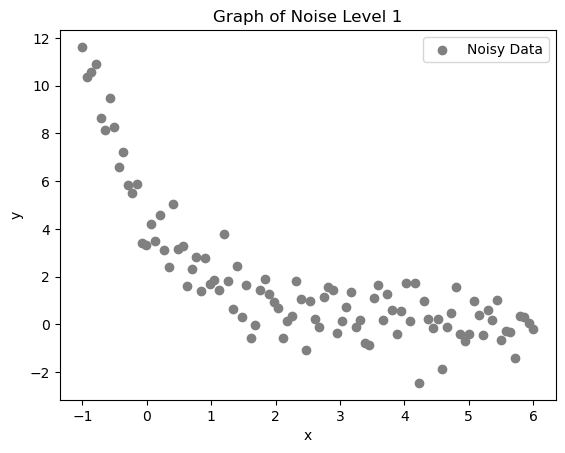

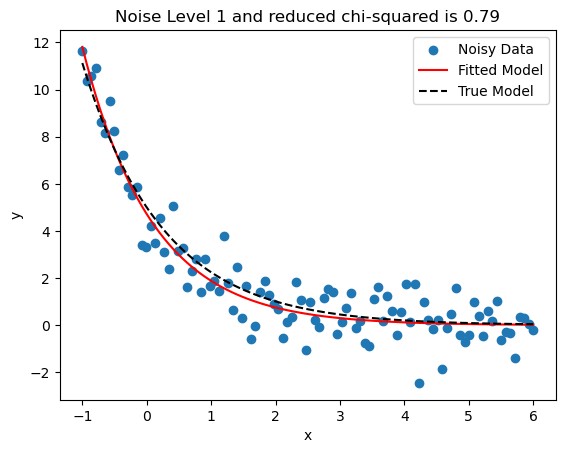

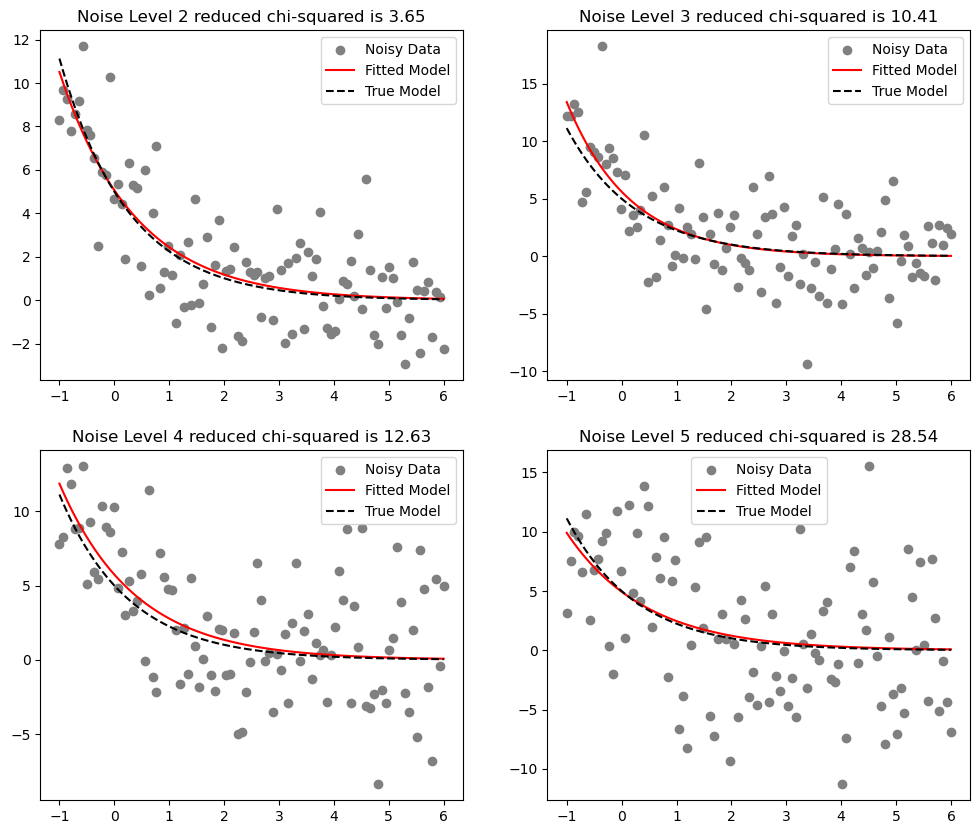

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

df = pd.read_csv('../../course_assignments/homework9/noisy_curvefit_data.csv')
df.shape # the shape of the dataset is (100, 6)
# there are 100 rows and 6 columns
print(df.head())
print(df.tail())
# the column names are: x , y noise 1, y noise 2, y noise 3, y noise 4, y noise 5
plt.scatter(df["x"], df["y_noise_1"], color = "gray", label = 'Noisy Data')
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Graph of Noise Level 1")
plt.show()
def model(x, A, k):
    return A * np.exp(-k * x)
p0 = [1, 1]
popt, pcov = curve_fit(model, df['x'], df['y_noise_1'], p0=p0)
A_fit, k_fit = popt
f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)"
residuals = df['y_noise_1'] - model(df['x'], A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(df['x']) - len(popt)
chi2_reduced = chi2 / dof
y_fit = model(df['x'], A_fit, k_fit)
plt.scatter(df['x'], df['y_noise_1'], label='Noisy Data')
plt.plot(df['x'], y_fit, color='red', label='Fitted Model')
plt.plot(df['x'], model(df['x'], 5, 0.8), color='black', linestyle='--', label='True Model')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title(f'Noise Level 1 and reduced chi-squared is {chi2_reduced:.2f}')
plt.show()
def fit_model(x, y):
    popt, pcov = curve_fit(model, x, y, p0 = [1, 1])
    y_fit = model(x, popt[0], popt[1])
    residuals = y - y_fit
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof
    return popt, chi2_reduced
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
noise_map = ['y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5']
a_fits = [A_fit] 
k_fits = [k_fit]
chi_sqs = [chi2_reduced]
for i, name in enumerate(noise_map):
    ax = axes[i]
    y = df[name]
    popt, reduced_chi = fit_model(df['x'], y)
    a_fits.append(popt[0])
    k_fits.append(popt[1])
    chi_sqs.append(reduced_chi)
    ax.scatter(df['x'], y, label='Noisy Data', color = 'gray')
    y_fit = model(df['x'], popt[0], popt[1])
    ax.plot(df['x'], y_fit, color='red', label='Fitted Model')
    ax.plot(df['x'], model(df['x'], 5, 0.8), color='black', linestyle='--', label='True Model')
    ax.set_title(f"Noise Level {name[-1]} reduced chi-squared is {reduced_chi:.2f}")
    ax.legend()
#As the noise level increases, the black dotted line remains while the red line moves away from the black line. as noise increases there is more random variation making it harder for the algorithm to find the exact parameters
#The value of the chi squared increases as the noise level goes up. higher noise results in larger residuals, larger residuals lead to a higher.
saved_data = {
    "Noise level": [1, 2, 3, 4, 5],
    "A_fit": a_fits, 
    "k_fit": k_fits, 
    "Reduced chi-squared": chi_sqs}
df = pd.DataFrame(saved_data)
df.to_csv("noisy_parameters.csv", index=False)